<a href="https://colab.research.google.com/github/WelfLowe/ML4non-programmers/blob/main/AI_in_social_science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# AI WORKSHOP NOTEBOOK



In [ ]:
from google.colab import drive
drive.mount('/content/drive')



## SETUP



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression

## TRACK A — QUALITATIVE CODING

### LLM SETUP (GEMINI API)

Set up your Google API Key from Colab secrets.
1. Create a key at https://aistudio.google.com/app/api-keys
2. Click the '🔑' icon in the left panel of Colab.
3. Add a new secret with the name 'GOOGLE_API_KEY' and paste your API key as the value.
4. Make sure to enable 'Notebook access' for this secret.

Alternatively, accept the answer and go to the next field.

In [ ]:
import google.generativeai as genai
from google.colab import userdata

GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)

def llm_call(prompt):
    model = genai.GenerativeModel('gemini-2.5-pro') # Using 'gemini-2.5-pro' model
    response = model.generate_content(prompt)
    return response.text

print("\n=== TRACK A: QUALITATIVE CODING (SWEDISH) ===")

texts_sv = [
    "Fråga: Samverkan inom brottsförebyggande arbete - hur görs den? | Data: Transkribering",
    "Fråga: Hur konstrueras maskulinitet och sexualitet i en online dopinggemenskap och i relation till dopingpraktikens kroppsliga effekter? | Data: Data från dopingforum såsom Flashback eller Thinksteroids.com",
    "Fråga: Ge förslag till utkast till en artikel i en vetenskaplig tidskrift. | Data: Delar ur en monografiavhandling",
    "Fråga: Hur skiljer sig stavningsutveckling hos elever som deltar i evidensbaserad läsundervisning från elever i 'teaching as usual'? | Data: Kvantitativ data från LegiLexis screening-test",
    "Fråga: Metaanalyser med omfattande data i open source som kan korsas longitudinellt och geografiskt med demografisk data. | Data: Open source-data om förmåner/bidrag kopplat till demografi",
    "Fråga: Hur positionerar sig Youtubekanalen Riks gentemot mainstreammedia? | Data: Youtube-videor analyserade med teoretisk analysram",
    "Fråga: Vilka möjligheter respektive utmaningar framträder kring ungdomars utbildning och arbetsmarknadens kompetensbehov? | Data: Styrgruppsprotokoll och regionala analyser",
    "Fråga: Identifiera möjligheter och utmaningar för tränare inom internationella SDP-insatser. | Data: Peer review-artiklar",
    "Fråga: Går det att använda AI för textanalys av fokusgruppintervjuer och är det tillförlitligt? | Data: Transkriberade fokusgruppintervjuer",
    "Fråga: Hur ser den inrikes omflyttningen av utrikes födda ut 2015–2025? | Data: SCB-data + intervjuer med migranter",
    "Fråga: Hur beskrivs barns omsorgsarbete i barnavårdsutredningar? | Data: Socialtjänstens utredningsdokument",
    "Fråga: Hur förändras kommuners tolkning av skolplaceringsregler för elever med NPF över tid? | Data: Policy och åtgärdsprogram",
    "Fråga: Omfattningen av centraliseringen av svensk förlossningsvård? | Data: Exempelvis Socialstyrelsens databas över födslar i Sverige",
    "Fråga: Hur upplever kemistudenter representationer av molekylorbitalteori? | Data: Stimulated recall-intervjuer + föreläsningsinspelningar",
    "Fråga: Hur kan AI användas i översiktlig analys av kvantdata? Ger olika modeller olika resultat? | Data: Kvantitativa dataset med variabler X och Y",
    "Fråga: Hur har synen på barnmisshandel förändrats 1950–2025 i Sverige? | Data: Dagstidningar och facktidskrifter"
    "Fråga: Hur upplever anhöriga till personer med hjärtsvikt användningen av ett internetbaserat stödprogram som riktar sig till målgruppen? | Data: Datan består av intervjuer med anhöriga (användare) som loggat in på stödprogrammet minst en gång i veckan under interventionen."
    "Fråga: Hur kan AI användas för att identifiera och analysera olika former av socialt stöd hos flickor som idrottar under puberteten? | Data: Kvalitativt intervjumaterial från flickor i puberteten som deltar i organiserad idrott, med fokus på upplevelser av socialt stöd från tränare, lagkompisar och familj."
]
kategorier_sv = [
    "Tydlig och direkt operationaliserbar",
    "Relativt tydlig men kräver precisering",
    "Otydlig eller för bred",
    "Fokuserar på AI-metod snarare än forskningsfråga",
    "Ej lämplig för AI utan omformulering"
]

# LLM coding example (now using Gemini API)
prompt = f"""
Koda följande AI fråggor och datakällor i kategorier:
{kategorier_sv}

Returnera resultatet som en parsbar JSON-array av objekt. Varje objekt ska ha följande nycklar: 'Fråga', 'Data', 'assigned Kategori', och 'Motivering'.

Texter:
{texts_sv}
"""
print("\nLLM-based coding results (using Gemini API):")

try:
    print(llm_call(prompt))
except Exception as e:
    # Check available models if generate_content failed
    print(f"Error during LLM call: {e}")
    print("Listing available models to diagnose the issue:")
    for m in genai.list_models():
        if 'generateContent' in m.supported_generation_methods:
            print(m.name)



=== TRACK A: QUALITATIVE CODING (SWEDISH) ===

LLM-based coding results (using Gemini API):
```json
[
  {
    "Fråga": "Samverkan inom brottsförebyggande arbete - hur görs den?",
    "Data": "Transkribering",
    "assigned Kategori": "Otydlig eller för bred",
    "Motivering": "Frågan är extremt bred ('hur görs den?') och datakällan ('Transkribering') är ospecificerad. För att bli operationaliserbar behöver frågan avgränsas till specifika aktörer, metoder eller kontexter för samverkan, och datan behöver beskrivas mer i detalj."
  },
  {
    "Fråga": "Hur konstrueras maskulinitet och sexualitet i en online dopinggemenskap och i relation till dopingpraktikens kroppsliga effekter?",
    "Data": "Data från dopingforum såsom Flashback eller Thinksteroids.com",
    "assigned Kategori": "Relativt tydlig men kräver precisering",
    "Motivering": "Frågan är väl avgränsad till en specifik kontext och datakälla. Däremot är begrepp som 'konstrueras maskulinitet och sexualitet' komplexa och kräve

In [ ]:
svar = """
json
[
  {
    "Fråga": "Samverkan inom brottsförebyggande arbete - hur görs den?",
    "Data": "Transkribering",
    "assigned Kategori": "Otydlig eller för bred",
    "Motivering": "Frågan är extremt bred ('hur görs den?') och datakällan ('Transkribering') är ospecificerad. För att bli operationaliserbar behöver frågan avgränsas till specifika aktörer, metoder eller kontexter för samverkan, och datan behöver beskrivas mer i detalj."
  },
  {
    "Fråga": "Hur konstrueras maskulinitet och sexualitet i en online dopinggemenskap och i relation till dopingpraktikens kroppsliga effekter?",
    "Data": "Data från dopingforum såsom Flashback eller Thinksteroids.com",
    "assigned Kategori": "Relativt tydlig men kräver precisering",
    "Motivering": "Frågan är väl avgränsad till en specifik kontext och datakälla. Däremot är begrepp som 'konstrueras maskulinitet och sexualitet' komplexa och kräver en tydlig teoretisk operationalisering (t.ex. vilka teman, diskurser eller språkliga mönster som ska identifieras) för att kunna analyseras med AI."
  },
  {
    "Fråga": "Ge förslag till utkast till en artikel i en vetenskaplig tidskrift.",
    "Data": "Delar ur en monografiavhandling",
    "assigned Kategori": "Tydlig och direkt operationaliserbar",
    "Motivering": "Detta är en tydligt definierad uppgift (generera ett artikelutkast) baserad på ett specifikt indata (avhandlingstext). Uppgiften är direkt lämpad för en stor språkmodell och kräver ingen ytterligare precisering för att kunna utföras."
  },
  {
    "Fråga": "Hur skiljer sig stavningsutveckling hos elever som deltar i evidensbaserad läsundervisning från elever i 'teaching as usual'?",
    "Data": "Kvantitativ data från LegiLexis screening-test",
    "assigned Kategori": "Tydlig och direkt operationaliserbar",
    "Motivering": "Frågan är en klassisk jämförande forskningsfråga med tydligt definierade grupper, utfallsmått (stavningsutveckling) och en specifik kvantitativ datakälla. Analysen kan direkt genomföras med statistiska AI-metoder."
  },
  {
    "Fråga": "Metaanalyser med omfattande data i open source som kan korsas longitudinellt och geografiskt med demografisk data.",
    "Data": "Open source-data om förmåner/bidrag kopplat till demografi",
    "assigned Kategori": "Ej lämplig för AI utan omformulering",
    "Motivering": "Detta är inte en forskningsfråga utan en beskrivning av en metod och en datatyp. För att vara lämplig för AI-analys måste en specifik, besvarbar forskningsfråga formuleras utifrån denna idé, t.ex. 'Vilken effekt har X på Y över tid och rum?'."
  },
  {
    "Fråga": "Hur positionerar sig Youtubekanalen Riks gentemot mainstreammedia?",
    "Data": "Youtube-videor analyserade med teoretisk analysram",
    "assigned Kategori": "Tydlig och direkt operationaliserbar",
    "Motivering": "Frågan är specifik och avgränsad till en aktör (Riks) och en relation (gentemot mainstreammedia). 'Positionering' kan operationaliseras genom att med AI analysera teman, sentiment och språkbruk i de angivna Youtube-videorna."
  },
  {
    "Fråga": "Vilka möjligheter respektive utmaningar framträder kring ungdomars utbildning och arbetsmarknadens kompetensbehov?",
    "Data": "Styrgruppsprotokoll och regionala analyser",
    "assigned Kategori": "Otydlig eller för bred",
    "Motivering": "Frågan är mycket bred och täcker flera stora ämnesområden (utbildning, arbetsmarknad, ungdomar). Begreppen 'möjligheter' och 'utmaningar' är vaga. För att bli hanterbar för AI-analys behöver frågan specificeras, t.ex. 'Vilka specifika kompetensglapp för unga identifieras i regionala analyser från perioden X?'."
  },
  {
    "Fråga": "Identifiera möjligheter och utmaningar för tränare inom internationella SDP-insatser.",
    "Data": "Peer review-artiklar",
    "assigned Kategori": "Relativt tydlig men kräver precisering",
    "Motivering": "Frågan är avgränsad till en specifik målgrupp och kontext. Dock är 'möjligheter och utmaningar' fortfarande generella begrepp som behöver definieras och operationaliseras (t.ex. vilka kategorier av utmaningar letar vi efter?) för att AI-modellen ska kunna extrahera relevant information från artiklarna på ett systematiskt sätt."
  },
  {
    "Fråga": "Går det att använda AI för textanalys av fokusgruppintervjuer och är det tillförlitligt?",
    "Data": "Transkriberade fokusgruppintervjuer",
    "assigned Kategori": "Fokuserar på AI-metod snarare än forskningsfråga",
    "Motivering": "Frågan handlar inte om innehållet i intervjuerna, utan om AI-metodens prestanda och tillförlitlighet för en viss typ av data. Detta är en metodologisk utvärdering, inte en forskningsfråga om ett sakförhållande."
  },
  {
    "Fråga": "Hur ser den inrikes omflyttningen av utrikes födda ut 2015–2025?",
    "Data": "SCB-data + intervjuer med migranter",
    "assigned Kategori": "Tydlig och direkt operationaliserbar",
    "Motivering": "Frågan är tydligt avgränsad i tid, population och fenomen. Den kvantitativa delen (analys av SCB-data) är direkt operationaliserbar med AI för att identifiera mönster. Den kvalitativa delen (intervjuer) kan användas för att berika och förklara mönstren."
  },
  {
    "Fråga": "Hur beskrivs barns omsorgsarbete i barnavårdsutredningar?",
    "Data": "Socialtjänstens utredningsdokument",
    "assigned Kategori": "Tydlig och direkt operationaliserbar",
    "Motivering": "Frågan är specifik och väl avgränsad. Med tillgång till dokumenten kan en AI tränas att identifiera och kategorisera hur 'barns omsorgsarbete' beskrivs, vilka ord och teman som används, och hur detta eventuellt varierar."
  },
  {
    "Fråga": "Hur förändras kommuners tolkning av skolplaceringsregler för elever med NPF över tid?",
    "Data": "Policy och åtgärdsprogram",
    "assigned Kategori": "Tydlig och direkt operationaliserbar",
    "Motivering": "Frågan är välformulerad med en tydlig longitudinell aspekt. 'Tolkning' kan operationaliseras genom att med AI analysera förändringar i språkbruk, nyckelbegrepp och argumentationslinjer i policydokument från olika tidsperioder."
  },
  {
    "Fråga": "Omfattningen av centraliseringen av svensk förlossningsvård?",
    "Data": "Exempelvis Socialstyrelsens databas över födslar i Sverige",
    "assigned Kategori": "Tydlig och direkt operationaliserbar",
    "Motivering": "Även om den är formulerad som ett påstående är avsikten tydlig: att kvantifiera centraliseringen. Detta är direkt mätbart med den föreslagna datakällan genom att analysera t.ex. antal förlossningskliniker och deras geografiska spridning över tid."
  },
  {
    "Fråga": "Hur upplever kemistudenter representationer av molekylorbitalteori?",
    "Data": "Stimulated recall-intervjuer + föreläsningsinspelningar",
    "assigned Kategori": "Relativt tydlig men kräver precisering",
    "Motivering": "Frågan är tydlig, men begreppet 'upplever' är komplext och mångfacetterat. För att AI-analys ska vara meningsfull krävs en precisering av vilka aspekter av upplevelsen som ska undersökas, t.ex. 'Vilka missförstånd är vanligast?' eller 'Vilka metaforer använder studenter för att beskriva teorin?'."
  },
  {
    "Fråga": "Hur kan AI användas i översiktlig analys av kvantdata? Ger olika modeller olika resultat?",
    "Data": "Kvantitativa dataset med variabler X och Y",
    "assigned Kategori": "Fokuserar på AI-metod snarare än forskningsfråga",
    "Motivering": "Frågan syftar till att undersöka AI som verktyg för dataanalys och jämföra olika AI-modellers resultat, snarare än att besvara en fråga om sambandet mellan X och Y i sig. Fokus ligger på metoden."
  },
  {
    "Fråga": "Hur har synen på barnmisshandel förändrats 1950–2025 i Sverige?",
    "Data": "Dagstidningar och facktidskrifter",
    "assigned Kategori": "Tydlig och direkt operationaliserbar",
    "Motivering": "Detta är en klassisk diakron studie som är mycket lämplig för AI-analys. 'Synen på' kan operationaliseras genom att spåra frekvensen av nyckelord, ämnesmodellering (topic modeling) och sentimentanalys i textmaterialet över den specificerade tidsperioden."
  },
  {
    "Fråga": "Hur upplever anhöriga till personer med hjärtsvikt användningen av ett internetbaserat stödprogram som riktar sig till målgruppen?",
    "Data": "Datan består av intervjuer med anhöriga (användare) som loggat in på stödprogrammet minst en gång i veckan under interventionen.",
    "assigned Kategori": "Relativt tydlig men kräver precisering",
    "Motivering": "Frågan är väl avgränsad till en specifik grupp och intervention. Begreppet 'upplever' är dock brett. En precisering behövs kring vilka dimensioner av upplevelsen som är i fokus (t.ex. användbarhet, emotionellt värde, tekniska problem) för att guida AI-analysen av intervjuerna."
  },
  {
    "Fråga": "Hur kan AI användas för att identifiera och analysera olika former av socialt stöd hos flickor som idrottar under puberteten?",
    "Data": "Kvalitativt intervjumaterial från flickor i puberteten som deltar i organiserad idrott, med fokus på upplevelser av socialt stöd från tränare, lagkompisar och familj.",
    "assigned Kategori": "Fokuserar på AI-metod snarare än forskningsfråga",
    "Motivering": "Formuleringen 'Hur kan AI användas för att...' placerar fokus på att utforska och demonstrera en AI-metods kapacitet för att lösa en viss typ av analysuppgift. Även om resultatet blir en analys av socialt stöd, är den primära frågeställningen metodologisk."
  }
]
"""

In [22]:
import json
import pandas as pd

# Parse the svar string into a Python list of dictionaries
data = json.loads(svar.replace('json', '', 1).strip())

# Extract the 'assigned Kategori' from each dictionary
kategorier = [entry['assigned Kategori'] for entry in data]

# Count the occurrences of each category and display frequencies
category_counts = pd.Series(kategorier).value_counts()
print("Frequencies of 'assigned Kategori':")
print(category_counts)

# Optionally, display as a DataFrame for better formatting
# display(pd.DataFrame(category_counts).rename(columns={0: 'Count'}))

Frequencies of 'assigned Kategori':
Tydlig och direkt operationaliserbar                8
Relativt tydlig men kräver precisering              4
Fokuserar på AI-metod snarare än forskningsfråga    3
Otydlig eller för bred                              2
Ej lämplig för AI utan omformulering                1
Name: count, dtype: int64


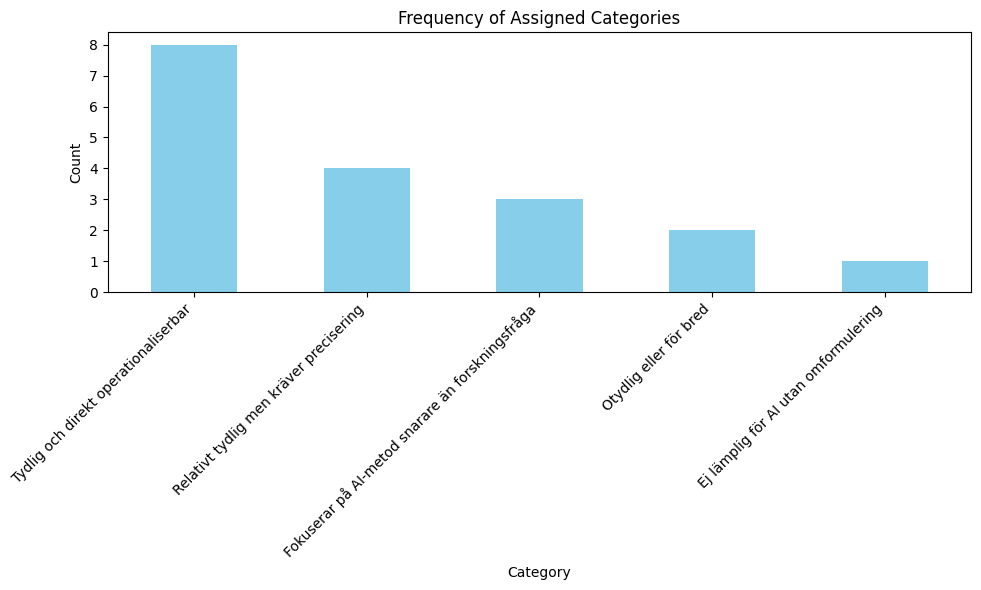

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
category_counts.plot(kind='bar', color='skyblue')
plt.title('Frequency of Assigned Categories')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



## TRACK B — ANALYZE DATA & CREATE ACTIONABLE MODELS


In [26]:
print("\n=== TRACK B: ANALYZE DATA & CREATE ACTIONABLE MODELS ===")

import pandas as pd
import json
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np

# --- data (same as before) ---

departments_sv = [
    "kriminologi och polisiärt arbete",
    "idrottsvetenskap",
    "pedagogik",
    "pedagogik",
    "kriminologi och polisiärt arbete",
    "statsvetenskap",
    "pedagogik",
    "idrottsvetenskap",
    "statsvetenskap",
    "Samhällsstudier",
    "socialt arbete",
    "pedagogik",
    "statsvetenskap",
    "pedagogik",
    "pedagogik",
    "socialt arbete",
    "socialt arbete",
    "idrottsvetenskap"
]

kategorier = [entry["assigned Kategori"] for entry in data]

df = pd.DataFrame({
    "Institution": departments_sv,
    "Fördröjning": list(range(len(departments_sv))),
    "Kategori": kategorier
})

print(df)

# ==============================================
# 1. ENCODE FEATURES
# ==============================================

# One-hot encode Institution
encoder = OneHotEncoder(sparse_output=False)
X_cat = encoder.fit_transform(df[["Institution"]])

# Add Fördröjning as numeric feature
X = np.hstack([X_cat, df[["Fördröjning"]].values])

# Encode target labels
label_enc = LabelEncoder()
y = label_enc.fit_transform(df["Kategori"])

# ==============================================
# 2. LINEAR "CLASSIFICATION" (via regression)
# ==============================================

lr = LinearRegression()
lr.fit(X, y)

# Predict + round to nearest class
y_pred_lr = np.round(lr.predict(X)).astype(int)

# Clip to valid class range
y_pred_lr = np.clip(y_pred_lr, y.min(), y.max())

# ==============================================
# 3. DECISION TREE CLASSIFIER (restricted depth)
# ==============================================

tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X, y)

y_pred_tree = tree.predict(X)



=== TRACK B: ANALYZE DATA & CREATE ACTIONABLE MODELS ===
                         Institution  Fördröjning  \
0   kriminologi och polisiärt arbete            0   
1                   idrottsvetenskap            1   
2                          pedagogik            2   
3                          pedagogik            3   
4   kriminologi och polisiärt arbete            4   
5                     statsvetenskap            5   
6                          pedagogik            6   
7                   idrottsvetenskap            7   
8                     statsvetenskap            8   
9                    Samhällsstudier            9   
10                    socialt arbete           10   
11                         pedagogik           11   
12                    statsvetenskap           12   
13                         pedagogik           13   
14                         pedagogik           14   
15                    socialt arbete           15   
16                    socialt arbete     

Confusion Matrix - Linear Regression (rounded):
[[0 1 0 0 0]
 [0 1 1 1 0]
 [0 1 0 1 0]
 [0 0 1 3 0]
 [0 0 0 4 4]]

Confusion Matrix - Decision Tree:
[[1 0 0 0 0]
 [0 1 0 1 1]
 [0 0 1 0 1]
 [0 0 0 4 0]
 [0 0 0 1 7]]


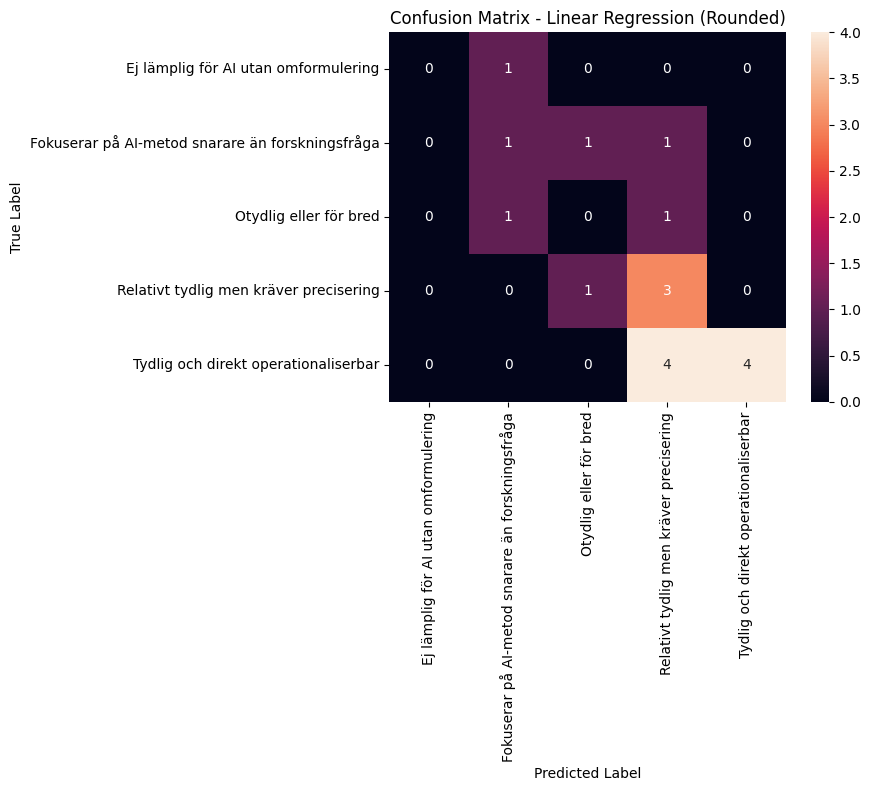

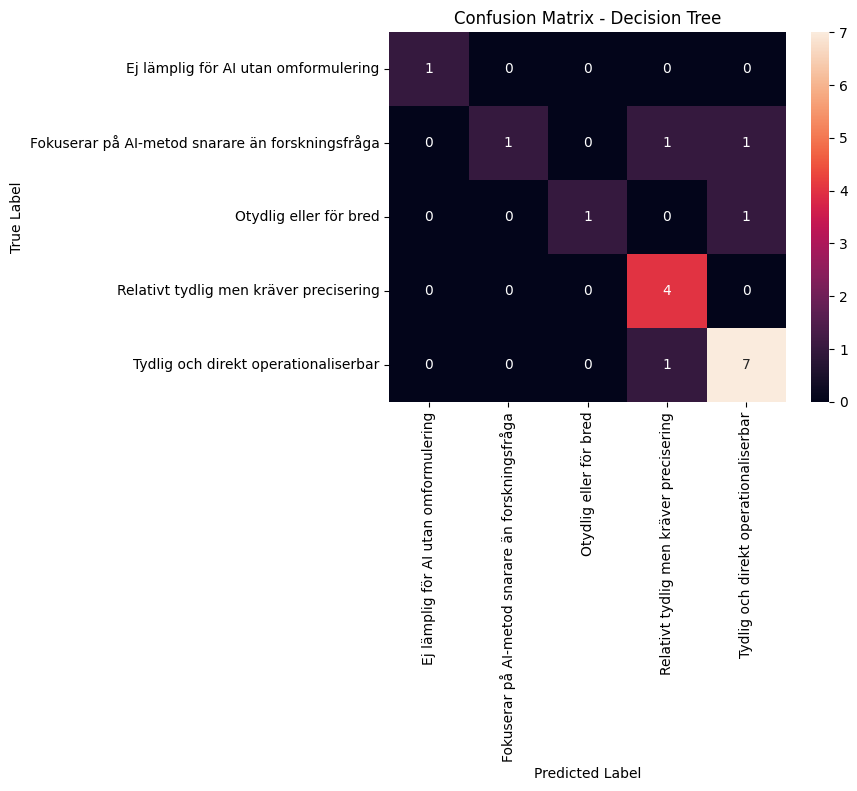

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================
# 4. CONFUSION MATRICES
# ==============================================

cm_lr = confusion_matrix(y, y_pred_lr)
cm_tree = confusion_matrix(y, y_pred_tree)

print("Confusion Matrix - Linear Regression (rounded):")
print(cm_lr)

print("\nConfusion Matrix - Decision Tree:")
print(cm_tree)

# Use class labels for axes
labels = label_enc.classes_

# ==============================================
# Linear Regression Confusion Matrix
# ==============================================
plt.figure()
sns.heatmap(cm_lr, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix - Linear Regression (Rounded)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# ==============================================
# Decision Tree Confusion Matrix
# ==============================================
plt.figure()
sns.heatmap(cm_tree, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## TRACK C — MEDIA ANALYSIS (SWEDISH)

In [ ]:
print("\n=== TRACK C: MEDIA ANALYSIS (SWEDISH) ===")

media_sv = [
    "Mainstreammedia ignorerar verkliga problem.",
    "Experter menar att situationen är under kontroll.",
    "Denna kanal är oberoende.",
    "Kritiker säger att vi överdriver.",
    "Traditionell journalistik har misslyckats."
]

vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(media_sv)

kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(X)

print("\nDiscourse clusters:")
for i, label in enumerate(kmeans.labels_):
    print(f"Text {i+1}: Cluster {label}")

# ==============================================
# REPRODUCIBILITY DEMO
# ==============================================
print("\n=== REPRODUCIBILITY CHECK ===")

for i in range(3):
    kmeans = KMeans(n_clusters=2)
    kmeans.fit(X)
    print(f"Run {i+1}: {kmeans.labels_}")

# ==============================================
# REFLECTION
# ==============================================
print("""
REFLECTION QUESTIONS:
1. Hur stabila är resultaten?
2. Skulle du lita på detta i en publikation?
3. Vad behöver valideras manuellt?
""")



=== TRACK C: MEDIA ANALYSIS (SWEDISH) ===

Discourse clusters:
Text 1: Cluster 1
Text 2: Cluster 0
Text 3: Cluster 0
Text 4: Cluster 1
Text 5: Cluster 1

=== REPRODUCIBILITY CHECK ===
Run 1: [0 0 0 0 1]
Run 2: [0 0 0 0 1]
Run 3: [0 0 0 0 1]

REFLECTION QUESTIONS:
1. Hur stabila är resultaten?
2. Skulle du lita på detta i en publikation?
3. Vad behöver valideras manuellt?

